# 🤖 2. Selective Preprocessing - Regression model with Dropouts
**Deep learning model for blue fundus eye pictures regression**

The purpose of this notebook is to evaluate a regression CNN model across different selective preprocessing scenarios.

The regression target is:

- `target_SE`: spherical equivalent value in diopters.

The same lightweight CNN architecture is trained on four preprocessing scenarios:The final purpose of this notebook is to apply last notebook's regession deep learning model (small_cnn_regrss) to different levels of preprocessing on the fundus images, so as to set a baseline for the project depending on the level of preprocessing. There will be 4 scenarios performed:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## ⚙️ 1. Setting up



In [1]:
from pathlib import Path #useful since it makes path use easier (can append paths and more)
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    validate_main_structure,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

IMAGES_DIR = paths["images"]
TABLES_DIR = paths["tables"]
SPLITS_DIR = paths["splits"]
MODELS_DIR = paths["models"]

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images dir:", IMAGES_DIR)
print("Tables dir:", TABLES_DIR)
print("Splits dir:", SPLITS_DIR)
print("Models dir:", MODELS_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Images dir: C:\Users\paula\0B_TFGBiomed_Exe\Images
Tables dir: C:\Users\paula\0B_TFGBiomed_Exe\Tables
Splits dir: C:\Users\paula\0B_TFGBiomed_Exe\Splits
Models dir: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Selective preprocessing output folders ===========================================================

SPLIT_ROOT = SPLITS_DIR / "Regression" / "SelectivePreproc"
MODELS_DIR_SELECTIVE = MODELS_DIR / "WithDropout" / "SelectivePreproc" / "Regression"

SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR_SELECTIVE.mkdir(parents=True, exist_ok=True)

print("Split root:", SPLIT_ROOT)
print("Models selective output:", MODELS_DIR_SELECTIVE)

Split root: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\SelectivePreproc
Models selective output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\SelectivePreproc\Regression


In [3]:
# Paths to selectively preprocessed sets of images
SCENARIO_TABLES = {
    "A_Raw_minimal": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx",         # Raw with minimal preproc
    "B_GeoNorm": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx",             # geometry + normalization
    "C_GeoNorm_Illum_NoAug": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx", # geometry + normalization + illumination 
    "D_GeoNorm_Aug_NoIllum": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx" # geometry + normalization + augmentations - there is no such path, will be using B for D
}

EXPERIMENTS = [ # (name, data_root, augment_in_loader, normalization)
    {
        "name": "A_Raw_minimal",
        "table": SCENARIO_TABLES["A_Raw_minimal"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "B_GeoNorm",
        "table": SCENARIO_TABLES["B_GeoNorm"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "C_GeoNorm_Illum_NoAug",
        "table": SCENARIO_TABLES["C_GeoNorm_Illum_NoAug"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "D_GeoNorm_Aug_NoIllum",
        "table": SCENARIO_TABLES["D_GeoNorm_Aug_NoIllum"],  #makes use of geom+norm to make augmentations without illumination
        "do_aug": True,
        "normalization": "0-1"
    }
]

for name, path in SCENARIO_TABLES.items():
    print(name, "exists:", path.exists(), "|", path)
    assert path.exists(), f"Missing scenario table: {path}"

A_Raw_minimal exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
B_GeoNorm exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
C_GeoNorm_Illum_NoAug exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
D_GeoNorm_Aug_NoIllum exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

####  2.1 Loading base table

In [4]:
base_df = pd.read_excel(SCENARIO_TABLES["A_Raw_minimal"])

# Keep only rows with valid paths and regression targets
base_df = base_df[base_df["image_path"].notna()].copy()
base_df = base_df[base_df["filename"].notna()].copy()
base_df = base_df[base_df["target_SE"].notna()].copy()

base_df["image_path"] = base_df["image_path"].astype(str)
base_df["filename"] = base_df["filename"].astype(str)
base_df["patient_id"] = base_df["patient_id"].astype(str).str.upper().str.strip()
base_df["target_SE"] = pd.to_numeric(base_df["target_SE"], errors="coerce")

base_df = base_df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE"]
).copy()

print("Total valid images for regression:", len(base_df))

print("\nTarget SE summary:")
print(base_df["target_SE"].describe())

base_df.head()

Total valid images for regression: 2126

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


#### ✂️  2.2 Splitting the dataset
Stratified (avoids bias since myope class is slightly bigger than the normal one) 80/10/10 split by chosen root dataset.

In [5]:
train_base_df, tmp_base_df = train_test_split(
    base_df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

val_base_df, test_base_df = train_test_split(
    tmp_base_df,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

print("Split sizes:")
print("Train:", len(train_base_df))
print("Validation:", len(val_base_df))
print("Test:", len(test_base_df))

print("\nTrain target SE summary:")
print(train_base_df["target_SE"].describe())

print("\nValidation target SE summary:")
print(val_base_df["target_SE"].describe())

print("\nTest target SE summary:")
print(test_base_df["target_SE"].describe())

Split sizes:
Train: 1700
Validation: 213
Test: 213

Train target SE summary:
count    1700.00000
mean        0.04625
std         2.14634
min       -20.37500
25%        -0.25000
50%         0.00000
75%         0.75000
max         9.00000
Name: target_SE, dtype: float64

Validation target SE summary:
count    213.000000
mean       0.037559
std        1.769741
min       -8.250000
25%       -0.250000
50%        0.000000
75%        0.625000
max        7.250000
Name: target_SE, dtype: float64

Test target SE summary:
count    213.000000
mean      -0.190141
std        2.117724
min      -10.750000
25%       -0.375000
50%        0.000000
75%        0.500000
max        7.750000
Name: target_SE, dtype: float64


In [6]:
def clean_regression_table(df): # Cleans one scenario table for regression training
    df = df.copy()

    df = df[df["image_path"].notna()].copy()
    df = df[df["filename"].notna()].copy()
    df = df[df["target_SE"].notna()].copy()

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
    df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")

    df = df.dropna(
        subset=["image_path", "filename", "patient_id", "target_SE"]
    ).copy()

    return df

def make_scenario_splits(exp): #Creates train/validation/test CSVs for one preprocessing scenario using the filenames from the base split
    name = exp["name"]
    table_path = exp["table"]

    scenario_df = pd.read_excel(table_path)
    scenario_df = clean_regression_table(scenario_df)

    train_files = set(train_base_df["filename"])
    val_files = set(val_base_df["filename"])
    test_files = set(test_base_df["filename"])

    train_s = scenario_df[scenario_df["filename"].isin(train_files)].copy()
    val_s = scenario_df[scenario_df["filename"].isin(val_files)].copy()
    test_s = scenario_df[scenario_df["filename"].isin(test_files)].copy()

    if len(train_s) != len(train_base_df):
        raise ValueError(f"{name}: train split mismatch.")
    if len(val_s) != len(val_base_df):
        raise ValueError(f"{name}: validation split mismatch.")
    if len(test_s) != len(test_base_df):
        raise ValueError(f"{name}: test split mismatch.")

    for split_name, split_df in [("train", train_s), ("val", val_s), ("test", test_s)]:
        missing = split_df["image_path"].apply(lambda p: not Path(p).exists()).sum()

        if missing > 0:
            examples = split_df[
                split_df["image_path"].apply(lambda p: not Path(p).exists())
            ]["image_path"].head(5).tolist()

            raise FileNotFoundError(
                f"{name} - {split_name}: {missing} paths do not exist. Examples: {examples}"
            )

    scenario_split_dir = SPLIT_ROOT / name
    scenario_split_dir.mkdir(parents=True, exist_ok=True)

    train_csv = scenario_split_dir / "train.csv"
    val_csv = scenario_split_dir / "val.csv"
    test_csv = scenario_split_dir / "test.csv"

    train_s.to_csv(train_csv, index=False)
    val_s.to_csv(val_csv, index=False)
    test_s.to_csv(test_csv, index=False)

    return train_csv, val_csv, test_csv


SCENARIO_SPLITS = {}

for exp in EXPERIMENTS:
    train_csv, val_csv, test_csv = make_scenario_splits(exp)

    SCENARIO_SPLITS[exp["name"]] = {
        "train": train_csv,
        "val": val_csv,
        "test": test_csv
    }

    print(f"{exp['name']}: regression splits saved successfully.")

A_Raw_minimal: regression splits saved successfully.
B_GeoNorm: regression splits saved successfully.
C_GeoNorm_Illum_NoAug: regression splits saved successfully.
D_GeoNorm_Aug_NoIllum: regression splits saved successfully.


#### 🧮  2.3 Decoder and normalizer
Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training. In other words, we are receiving a disk path and giving a tensor back.

Note: a tensor is the basic structure in TensorFlow (in deep learning frameworks). A picture would be a 3D tensor (hxwxchannels) and a batch of pictures would be a 4D tensor (hxwxcxbatch)

In [7]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], tf.float32) #mean pixels intensity on red, green, blue channels
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], tf.float32) #standard deviations on channels

def decode_img(path, label, normalization="0-1"):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) #decodes jpg into rgb tensor
    img = tf.image.convert_image_dtype(img, tf.float32) #converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    img = normalize_tensor(img, mode=normalization)
    return img, tf.cast(label, tf.float32) #gives pic+label back so dataloader knows the class it belongs to 

def normalize_tensor(img_float01, mode="0-1"):
    # img_float01 into [0,1], float32
    if mode == "0-1":
        return img_float01
    if mode == "imagenet":
        return (img_float01 - IMAGENET_MEAN) / IMAGENET_STD
    if mode == "zscore":
        mean = tf.reduce_mean(img_float01, axis=[0,1], keepdims=True)
        std  = tf.math.reduce_std(img_float01, axis=[0,1], keepdims=True) + 1e-6
        return (img_float01 - mean) / std
    return img_float01

#### 🎭  2.4 Dataloader with(out) Lightweight augmentations
Creating the TensorFlow dataset (dataloader) with simple geometric transformations (or not) to improve generalization and reduce overfitting.

Shuffles and augmentations will only be applied if training=True

In [8]:
#Declare the type of augmentations to be carried out (if wanted)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])

def make_ds(csv_path, training=False, normalization="0-1", do_aug=False): #creating the TensorFlow dataset
    split_df = pd.read_csv(csv_path) #cvs path is pic+label
    paths = split_df["image_path"].astype(str).values
    targets = split_df["target_SE"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y, normalization), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if training, it shuffles (so it learns with random order) and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        if do_aug:
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE) #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster; batch size declared up top
    return ds

#### 🟢  2.5 The regression model - small_cnn_regrss

Definition of the small_cnn architecture used as a first baseline regression model. This was model small_cnn_regrss on the Models_1FullPreproc.ipynb notebook.

In [9]:
def build_small_cnn_regrss(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="linear")(x) # Regression output: one continuous value, e.g. -2.75 diopters
    return keras.Model(inputs, outputs)

def compile_model_regrss():
    model_regrss = build_small_cnn_regrss()
    model_regrss.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with low error 
                  loss="mse", #adecuate for regression calculations (Mean Squared Error)
                  metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.MeanSquaredError(name="mse")]) #Mean Absolute Error and accuracy metrics
    return model_regrss

In [10]:
example_model = compile_model_regrss()
example_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️  2.6 Callbacks
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

In [11]:
def make_callbacks():
    return [ 
        keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
        keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
    ]

#### 📦  2.7 Training and evalutation wrappers
Utility functions to make predictions on the dataset and evaluate results by stablished metrics.

In [12]:
#This function gives back true labels and predicted labels so as to calculate metrics later on
def collect_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] 
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    return y_true, y_score

#Gives back a dictionary with: model name, AUC, AP, accuracy @50% threshold, confusion matrix and classification report
def evaluate_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_preds(model, test_ds)
    
    errors = y_pred - y_true
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    #Metric 1: ROC / PR???
    if len(y_true) >= 2:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    #Metric 2: Confusion matrix & report???
    if show_plots:
        plt.figure(figsize=(5, 5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2) if not np.isnan(r2) else np.nan,
        "mean_error": float(np.mean(errors)),
        "std_error": float(np.std(errors))
    }

#### 🧪  2.8 Running the experiment
Full pipeline of model.

In [13]:
def run_experiment(exp, epochs=10):
    name = exp["name"]
    normalization = exp["normalization"]
    do_aug = exp["do_aug"]

    print(f"\n===== Running {name} =====")

    # 1) Splits (by root)
    train_csv = SCENARIO_SPLITS[name]["train"]
    val_csv = SCENARIO_SPLITS[name]["val"]
    test_csv = SCENARIO_SPLITS[name]["test"]

    # 2) Datasets
    train_ds = make_ds(train_csv, training=True,  normalization=normalization, do_aug=do_aug)
    val_ds   = make_ds(val_csv,   training=False, normalization=normalization, do_aug=False)
    test_ds  = make_ds(test_csv,  training=False, normalization=normalization, do_aug=False)

    # 3) Model
    model = compile_model_regrss()
    
    # 4) callbacks
    cb = make_callbacks()

    # 5) Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb)

    # 6) Evaluate
    test_metrics = evaluate_on_test(name, model, test_ds, show_plots=True)
    print(test_metrics)
    
    return model, history, test_metrics, (train_ds, val_ds, test_ds)


## 🚀 3. The launching of the model

Now, we'll launch the regression (small_cnn_regrss), that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

We'll be applying it on the 4 baselines:

🇦 2.1 Small CNN with raw images - Mere normalization.

🇧 2.2 Small CNN with no Illumination and no Augmentations - This time only geometry and normalization preprocessing are applied.

🇨 2.3 Small CNN with Illumination (no augmentations) - This time only geometry, normalization and illumination preprocessing are applied.

🇩 2.4 Small CNN with Augmentations (no illumination) - This time only geometry, normalization and augmentations are applied.


===== Running A_Raw_minimal =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - loss: 4.1817 - mae: 1.1885 - mse: 4.1817 - val_loss: 3.1208 - val_mae: 1.0420 - val_mse: 3.1208 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - loss: 4.5422 - mae: 1.1690 - mse: 4.5422 - val_loss: 3.0810 - val_mae: 1.0312 - val_mse: 3.0810 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - loss: 4.1225 - mae: 1.1626 - mse: 4.1225 - val_loss: 3.0820 - val_mae: 1.0324 - val_mse: 3.0820 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - loss: 4.4575 - mae: 1.1810 - mse: 4.4575 - val_loss: 3.0339 - val_mae: 1.0419 - val_mse: 3.0339 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - loss: 4.4451 - mae: 1.2495 - mse: 4.4451 - val_loss: 3.0099 - val_mae: 1.0502 - val_mse: 3.0099 - learning_rate: 3.0000e-04
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - loss: 4.2041 - mae: 1.2187 - mse: 4.2041 - 

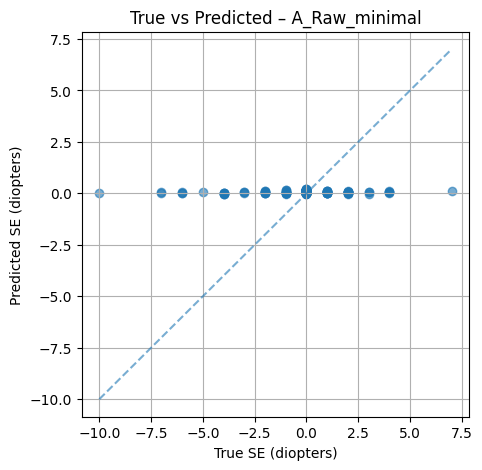

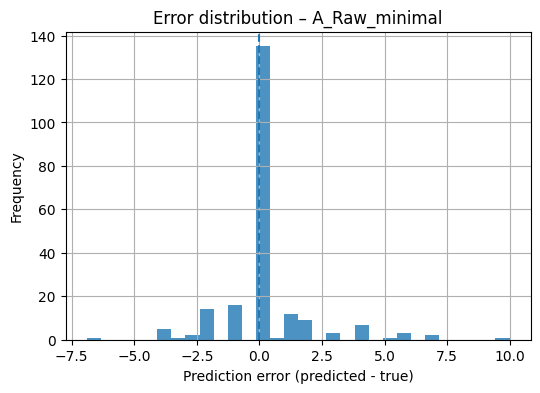

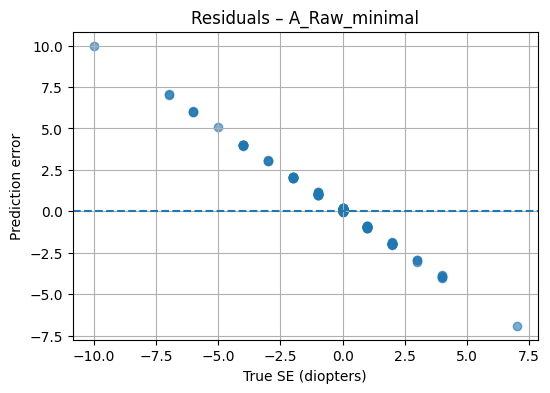

{'name': 'A_Raw_minimal', 'MAE': 0.9537890531371912, 'MSE': 3.5014386369789796, 'RMSE': 1.8712131457904466, 'R2': -0.006148547186573428, 'mean_error': 0.22221109881656062, 'std_error': 1.8579722453636693}

===== Running B_GeoNorm =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - loss: 4.1945 - mae: 1.1904 - mse: 4.1945 - val_loss: 3.0962 - val_mae: 1.0249 - val_mse: 3.0962 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 927ms/step - loss: 4.5248 - mae: 1.1639 - mse: 4.5248 - val_loss: 3.0580 - val_mae: 1.0324 - val_mse: 3.0580 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - loss: 4.1118 - mae: 1.1691 - mse: 4.1118 - val_loss: 3.0734 - val_mae: 1.0300 - val_mse: 3.0734 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 980ms/step - loss: 4.4409 - mae: 1.1742 - mse: 4.4409 - val_loss: 3.0278 - val_mae: 1.0443 - val_mse: 3.0278 - learning_rate: 3.0000e-04
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 972ms/step - loss: 4.445

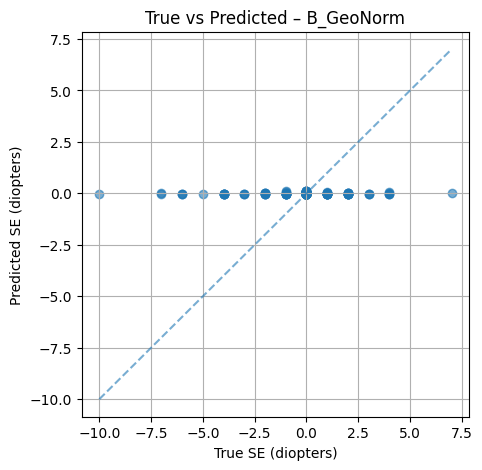

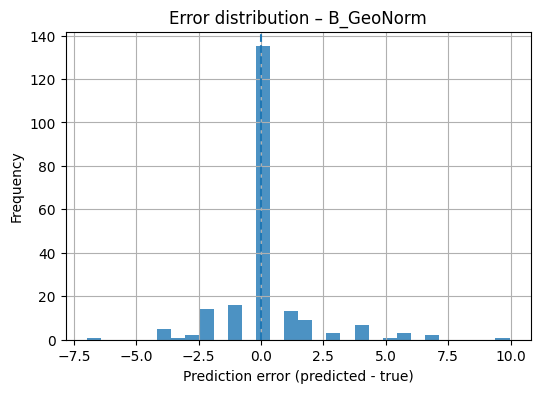

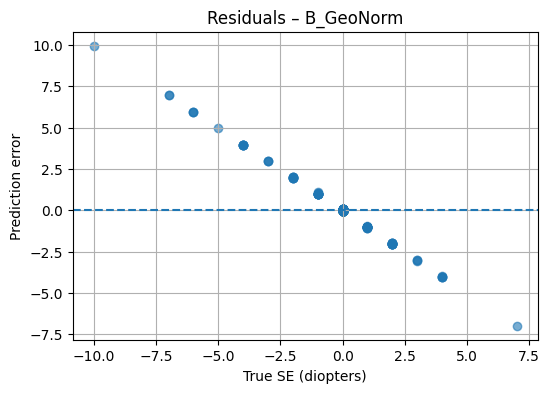

{'name': 'B_GeoNorm', 'MAE': 0.9331191305268967, 'MSE': 3.49007268039154, 'RMSE': 1.8681736215864788, 'R2': -0.002882506597695844, 'mean_error': 0.156638372688939, 'std_error': 1.8615953106389425}

===== Running C_GeoNorm_Illum_NoAug =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 4.1927 - mae: 1.1906 - mse: 4.1927 - val_loss: 3.1111 - val_mae: 1.0238 - val_mse: 3.1111 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 55s 964ms/step - loss: 4.5379 - mae: 1.1574 - mse: 4.5379 - val_loss: 3.0963 - val_mae: 1.0285 - val_mse: 3.0963 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 4.1309 - mae: 1.1567 - mse: 4.1309 - val_loss: 3.0845 - val_mae: 1.0335 - val_mse: 3.0845 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 968ms/step - loss: 4.4621 - mae: 1.1746 - mse: 4.4621 - val_loss: 3.0588 - val_mae: 1.0264 - val_mse: 3.0588 - learning_rate: 3.0000e-04
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - loss: 4.45

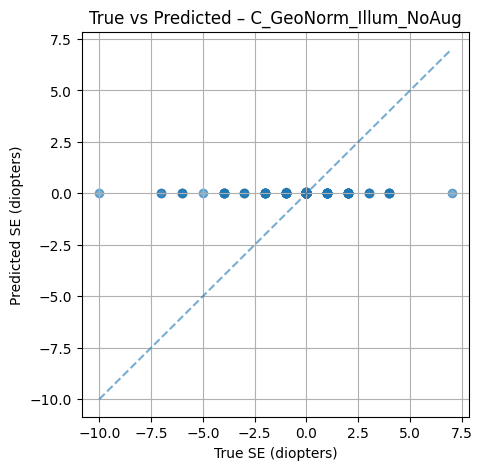

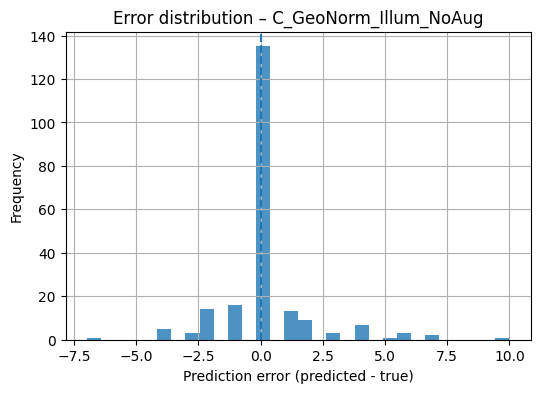

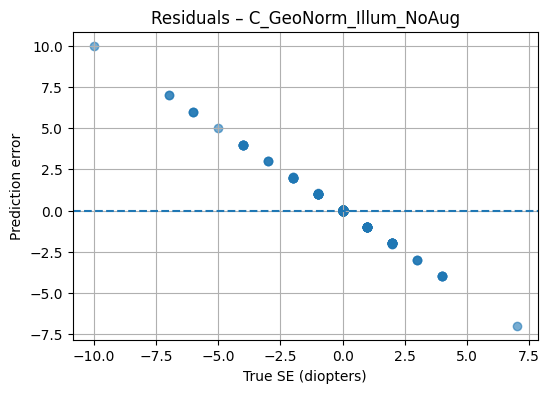

{'name': 'C_GeoNorm_Illum_NoAug', 'MAE': 0.9215733472707663, 'MSE': 3.5068219759255275, 'RMSE': 1.8726510555694906, 'R2': -0.007695465245590283, 'mean_error': 0.17301304421815017, 'std_error': 1.8646416445140057}

===== Running D_GeoNorm_Aug_NoIllum =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - loss: 4.1882 - mae: 1.1921 - mse: 4.1882 - val_loss: 3.1234 - val_mae: 1.0709 - val_mse: 3.1234 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - loss: 4.5211 - mae: 1.1804 - mse: 4.5211 - val_loss: 3.0590 - val_mae: 1.0357 - val_mse: 3.0590 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 4.1152 - mae: 1.1742 - mse: 4.1152 - val_loss: 3.0739 - val_mae: 1.0314 - val_mse: 3.0739 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - loss: 4.4414 - mae: 1.1829 - mse: 4.4414 - val_loss: 3.0595 - val_mae: 1.0923 - val_mse: 3.0595 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - 

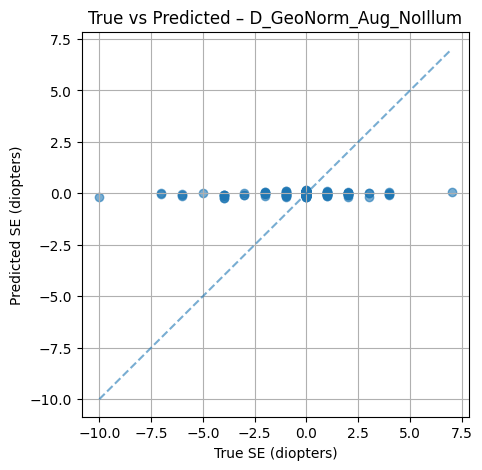

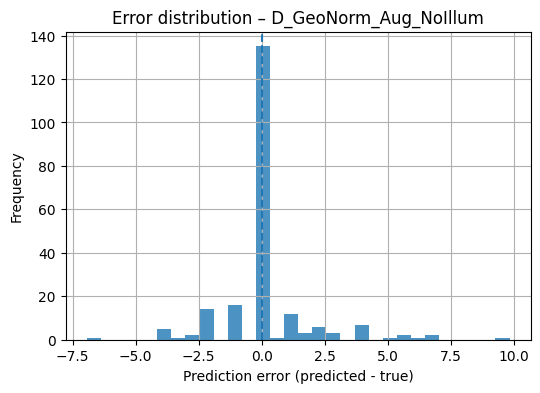

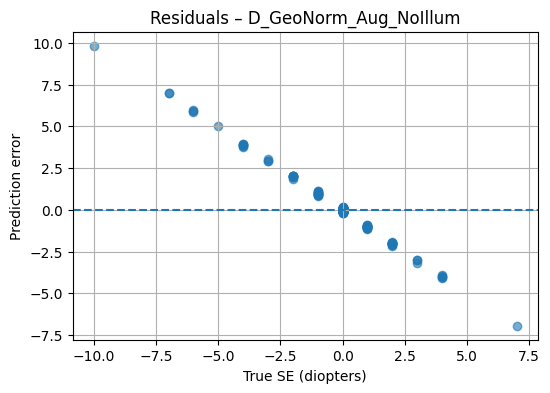

{'name': 'D_GeoNorm_Aug_NoIllum', 'MAE': 0.9489531125654707, 'MSE': 3.4563446016007746, 'RMSE': 1.8591246869429643, 'R2': 0.006809354660795908, 'mean_error': 0.14950813446193933, 'std_error': 1.8531033212777115}


,name,task,preprocessing_family,dropout,augmentation,normalization,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2,mean_error,std_error,model_path
0,A_Raw_minimal,regression,SelectivePreproc,True,False,0-1,1.031188,3.008965,0.953789,3.501439,1.871213,-0.006149,0.222211,1.857972,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,B_GeoNorm,regression,SelectivePreproc,True,False,0-1,1.024867,3.009762,0.933119,3.490073,1.868174,-0.002883,0.156638,1.861595,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,C_GeoNorm_Illum_NoAug,regression,SelectivePreproc,True,False,0-1,1.023831,3.022907,0.921573,3.506822,1.872651,-0.007695,0.173013,1.864642,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,D_GeoNorm_Aug_NoIllum,regression,SelectivePreproc,True,True,0-1,1.031376,3.012548,0.948953,3.456345,1.859125,0.006809,0.149508,1.853103,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


In [14]:
results = []
models  = {}
histories = {}
datasets = {}

for exp in EXPERIMENTS:
    mdl, hist, metrics, ds_tuple = run_experiment(exp, epochs=10)

    name = exp["name"]
    models[name] = mdl
    histories[name] = hist
    datasets[name] = ds_tuple

    model_path = MODELS_DIR_SELECTIVE / f"small_cnn_regression_with_dropout_{name}.keras"
    mdl.save(model_path)

    results.append({
        "name": name,
        "task": "regression",
        "preprocessing_family": "SelectivePreproc",
        "dropout": True,
        "augmentation": exp["do_aug"],
        "normalization": exp["normalization"],
        "best_val_mae": float(np.min(hist.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(hist.history.get("val_mse", [np.nan]))),
        "test_mae": metrics["MAE"],
        "test_mse": metrics["MSE"],
        "test_rmse": metrics["RMSE"],
        "test_r2": metrics["R2"],
        "mean_error": metrics["mean_error"],
        "std_error": metrics["std_error"],
        "model_path": str(model_path)
    })

results_df = pd.DataFrame(results)
results_df

The results table shows a comparative of the same model (small_cnn_classf) run over the 4 different sets of preprocessed pictures:
- best_val_auc: best AUC value (capacity of model to distinguish classes) obtained accross the 10 epochs on the **validation set** (1 perfect, 0.5 random)
- best_val_acc: best accuracy value (% of right guesses) obtained accross the 10 epochs on the **validation set** (watch out for unbalanced classes in dataset)
- test_auc: AUC obtained on **test set**. This might be the most important metric
- test_ap: average precision obtained on **test set** (area under precision-recall curve). Very useful with unbalanced classes since it focuses on performance on myopia class
- test_acc@0.5: accuracy obtained on **test set** when 0.5 threshold is applied (≥ 0.5 means myopia); < 0.5 means normal)

All in all:
- AUC shows how well the model distinguishes amongst classes
- Accuracy shows % of right guesses when classifying
- AP shows how well the model handles the minority class (looking at precision vs recall)

**The best performance (by all metrics) was carried out by level XXX of preprocessing (geom + norm + illum - augms), last one being level XXX (geom + norm - illum + augms)**

Note 1: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Note 2: handling the smaller class (AP) can be complicated since, if there is a large picture number difference amongst classes, the model might learn to state it is almost always right to predict that a picture belongs to the larger group when classifying.

## 📊 4. Results

#### 📈 4.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for Keras models, making it easy to compare performance across epochs.

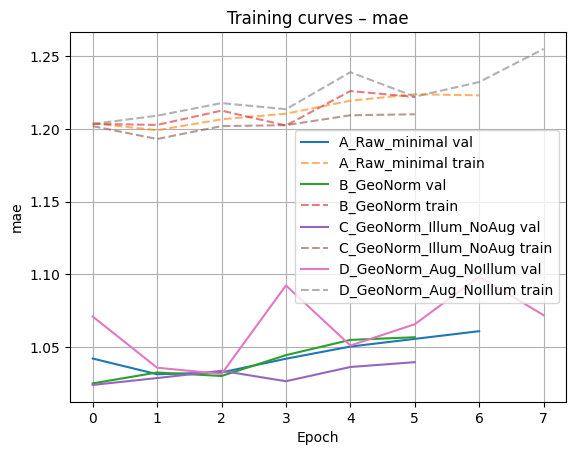

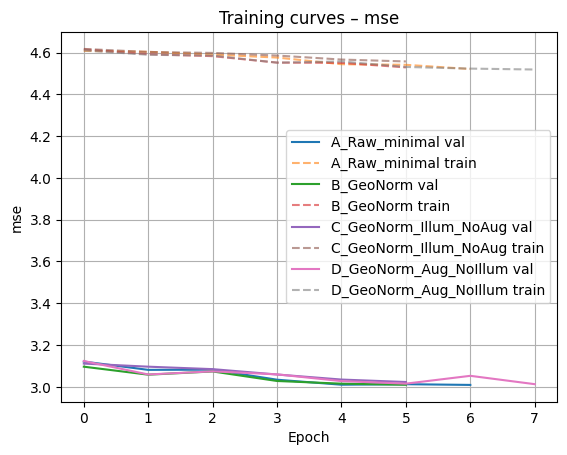

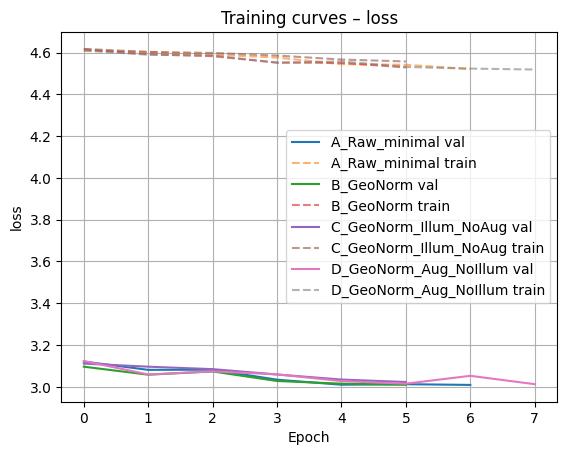

In [15]:
def plot_histories(histories, metric="mae"):
    #histories: list of keras History objects
    for name, history in histories.items():
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"{name} val")

        if metric in history.history:
            plt.plot(
                history.history[metric],
                linestyle="--",
                alpha=0.6,
                label=f"{name} train"
            )

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training curves – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

#Let's have them set side by side to compare
plot_histories(histories, metric="mae")
plot_histories(histories, metric="mse")
plot_histories(histories, metric="loss")

#### ⚖️ 4.2 Direct comparison A vs B vs C vs D on ROC & PR
This code evaluates multiple outcomes on the same test set, computes ROC and Precision–Recall curves (with AUC and AP), and overlays the curves to compare their performance directly.

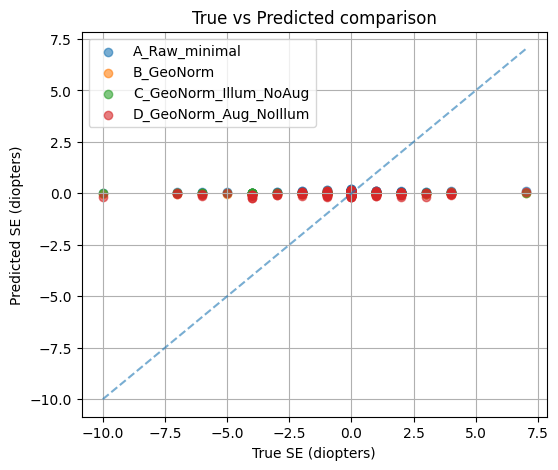

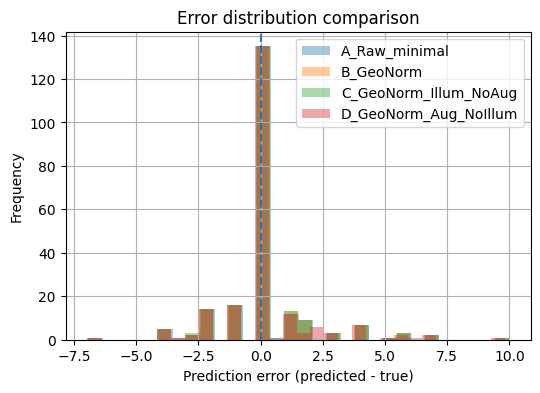

In [16]:
def compare_models_on_test(model_dict, scenario_splits, normalization="0-1"):
    comparison = {}

    for name, model in model_dict.items():
        test_csv = scenario_splits[name]["test"]

        test_ds = make_ds(test_csv, training=False, normalization=normalization, do_aug=False)
        y_true, y_pred = collect_preds(model, test_ds)
        errors = y_pred - y_true

        comparison[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "errors": errors
        }

    plt.figure(figsize=(6, 5))
    
    for name, d in comparison.items():
        plt.scatter(d["y_true"], d["y_pred"], alpha=0.6, label=name)

    all_true = np.concatenate([d["y_true"] for d in comparison.values()])
    all_pred = np.concatenate([d["y_pred"] for d in comparison.values()])

    min_val = min(all_true.min(), all_pred.min())
    max_val = max(all_true.max(), all_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)
    plt.xlabel("True SE (diopters)")
    plt.ylabel("Predicted SE (diopters)")
    plt.title("True vs Predicted comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(6, 4))

    for name, d in comparison.items():
        plt.hist(d["errors"], bins=30, alpha=0.4, label=name)

    plt.axvline(0, linestyle="--")
    plt.xlabel("Prediction error (predicted - true)")
    plt.ylabel("Frequency")
    plt.title("Error distribution comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    return comparison


regression_comparison = compare_models_on_test(
    models,
    SCENARIO_SPLITS,
    normalization="0-1"
)

It is pretty clear all levels of preprocessing did well, **being slighlty better level XXX (draws more angled ROC and P-R curves).**

#### 📝 4.3 Conclusions

So as a conclusion, this **regression model (small_cnn_regrss) performed pretty well across all preprocessings, obtaining slightly better results on XXXX** for:
- Distinguishing between classes on test (AUC) = XXX (val) and *XXX*(test)
- Classifying more accurately, globally (accuracy) = *XXX* (val) and *XXX* (test)
- Doing a better job at handling the smaller class (myopia) in terms of precision-recall (AP) = *XXX* (test)

On the other hand, the small_cnn_regrss on the fully preprocessed model (Models_1FullPreproc notebook) gave us the following results:
- Distinguishing a bit better between classes on validation (AUC) = *XXX* (val) and XXX(test)
- Classifying less accurately, globally (accuracy) = XXX (val) and XXX (test)
- Doing a slightly worse job at handling the smaller class (myopia) in terms of precision-recall (AP) = XXX (test)

The **full preprocessed model** (small_cnn_regrss on notebook 1, with the complete pipeline) achieves excellent metrics, but it **does not outperform preprocessing level XXX** (GeoNorm+Illum, no Aug), which generally delivers slightly better results on both validation and test.

Interestingly, **adding augmentations** in level XXX (GeoNorm+Aug, no Illum) actually **decreases accuracy in validation and test**.

Both level XXX (Raw minimal) and XXX (GeoNorm only) also perform remarkably well, although slightly below level XXX with this small_cnn_regrss.

End :)